In [ ]:
import ast
import pandas as pd
import os

def process_large_gyafc_file(file_path, label, is_target=False):
    """
    Xử lý tệp tin GYAFC quy mô lớn.
    - file_path: Đường dẫn tới tệp .src hoặc .tgt
    - label: 0 cho Informal, 1 cho Formal
    - is_target: True nếu là file .tgt (chứa list), False nếu là .src (chứa câu đơn)
    """
    processed_rows = []

    if not os.path.exists(file_path):
        print(f"Cảnh báo: Không tìm thấy tệp {file_path}")
        return []

    print(f"Đang xử lý: {file_path}...")

    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue

            if is_target:
                try:
                    # Chuyển chuỗi dạng list thành list thật
                    sentences = ast.literal_eval(line)
                    for sent in sentences:
                        processed_rows.append({'text': sent, 'label': label})
                except Exception as e:
                    # Bỏ qua dòng lỗi nhưng vẫn báo cáo vị trí
                    continue
            else:
                # File .src thường là mỗi dòng 1 câu informal
                processed_rows.append({'text': line, 'label': label})

    print(f"-> Hoàn thành. Trích xuất được {len(processed_rows)} câu.")
    return processed_rows

# --- BẮT ĐẦU CHẠY ---
# Giả sử bạn có các file này trong thư mục Colab
all_data = []

# 1. Xử lý file Target (Formal) - Đổi is_target thành False
all_data.extend(process_large_gyafc_file('drive/MyDrive/dataset_KHDL/gyafc_fr/train.tgt', label=1, is_target=False))

# 2. Xử lý file Source (Informal)
all_data.extend(process_large_gyafc_file('drive/MyDrive/dataset_KHDL/gyafc_fr/train.src', label=0, is_target=False))

# Chuyển thành DataFrame và trộn
final_df = pd.DataFrame(all_data)
final_df = final_df.sample(frac=1).reset_index(drop=True)

# In tổng kết
print(f"\nTổng số mẫu dữ liệu: {len(final_df)}")
print(final_df['label'].value_counts())

Đang xử lý: drive/MyDrive/dataset_KHDL/gyafc_fr/train.tgt...
-> Hoàn thành. Trích xuất được 51967 câu.
Đang xử lý: drive/MyDrive/dataset_KHDL/gyafc_fr/train.src...
-> Hoàn thành. Trích xuất được 51967 câu.

Tổng số mẫu dữ liệu: 103934
label
1    51967
0    51967
Name: count, dtype: int64


In [ ]:
final_df.to_csv('drive/MyDrive/dataset_KHDL/gyafc_dataset_train_full.csv', index=False)
print("Đã lưu file thành công!")

Đã lưu file thành công!


--- KHÁM SỨC KHỎE DỮ LIỆU TỔNG QUAN ---
Tổng số dòng: 103934
Có dòng nào bị thiếu dữ liệu không? 
text          0
label         0
label_name    0
word_count    0
dtype: int64


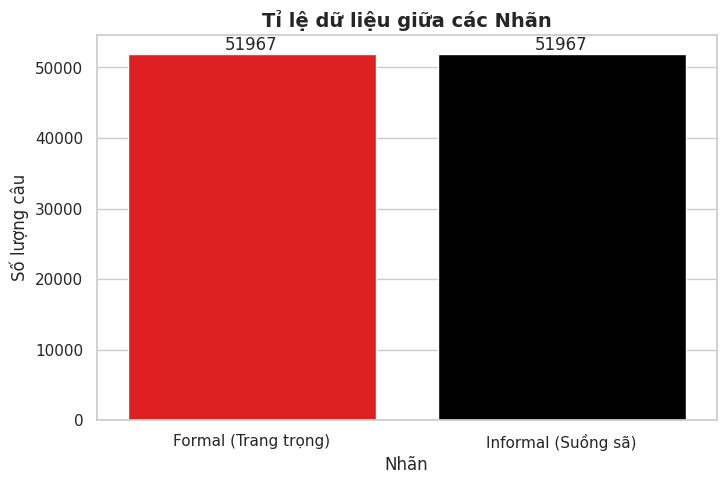

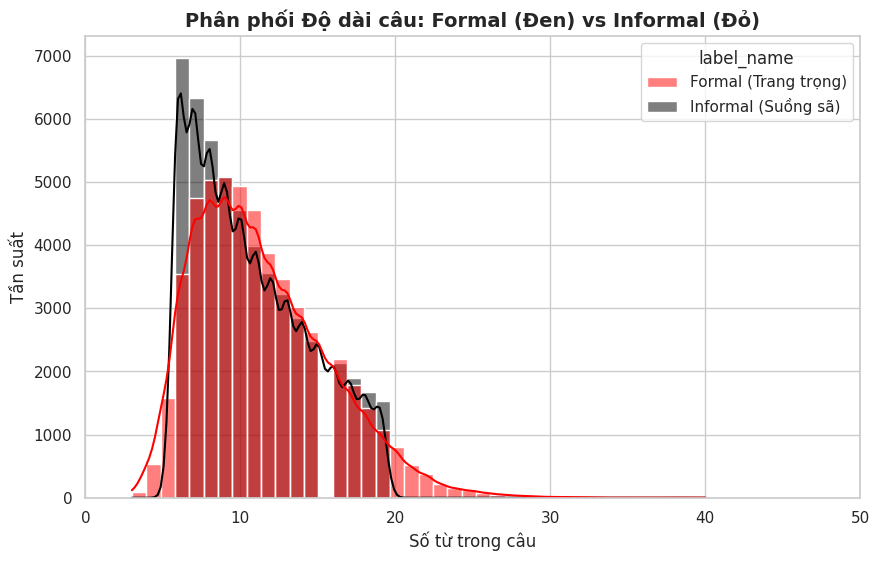

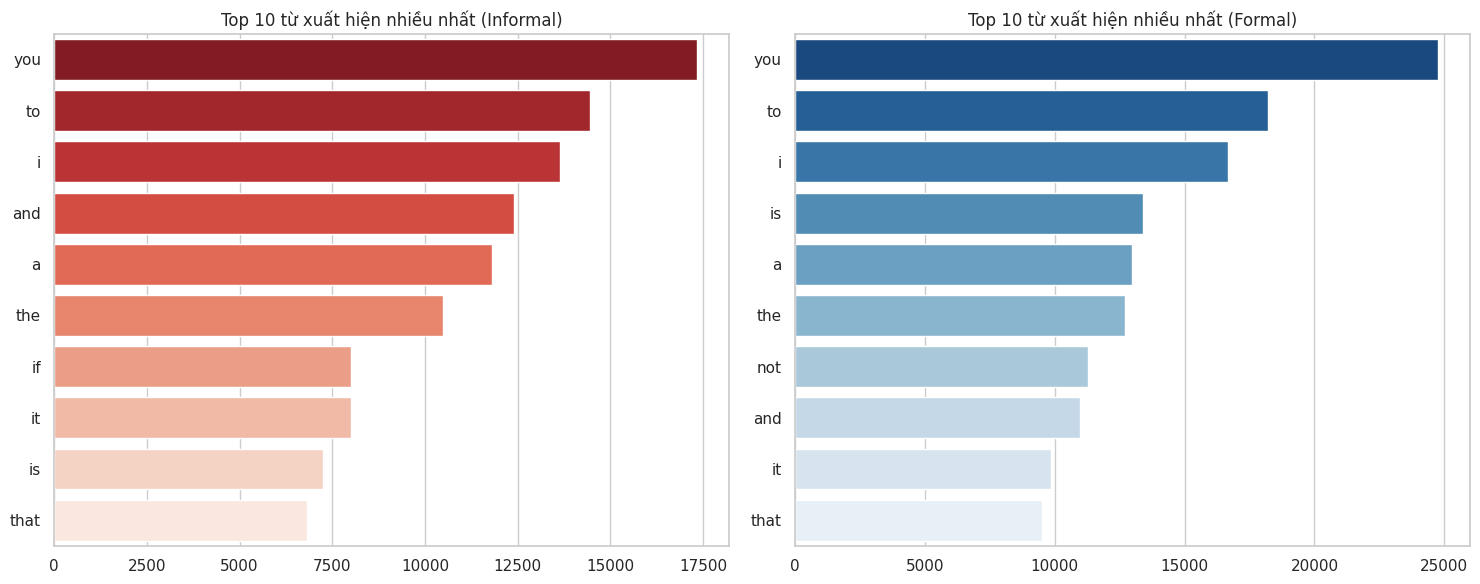

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. ĐỌC DỮ LIỆU TỪ GOOGLE DRIVE
# Giả sử bạn đã lưu file ở bước trước. Hãy thay đổi đường dẫn nếu bạn lưu ở chỗ khác.
file_path = '/content/drive/MyDrive/dataset_KHDL/gyafc_dataset_train_full.csv'
# (Nếu bạn chưa lưu lên drive, cứ đổi lại thành 'gyafc_dataset_full.csv' nếu file đang ở trên Colab)
df = pd.read_csv(file_path)

# Thêm cột bổ trợ
df['label_name'] = df['label'].map({0: 'Informal (Suồng sã)', 1: 'Formal (Trang trọng)'})
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Thiết lập màu sắc tùy chỉnh: Đỏ cho Informal (0), Đen cho Formal (1)
custom_palette = ['red', 'black']

print("--- KHÁM SỨC KHỎE DỮ LIỆU TỔNG QUAN ---")
print(f"Tổng số dòng: {df.shape[0]}")
print(f"Có dòng nào bị thiếu dữ liệu không? \n{df.isnull().sum()}")

# Thiết lập phong cách biểu đồ cho đẹp mắt
sns.set_theme(style="whitegrid")

# ==========================================
# KHÍA CẠNH 1: ĐỘ CÂN BẰNG NHÃN (CLASS BALANCE)
# ==========================================
plt.figure(figsize=(8, 5))
# Ánh xạ nhãn 0, 1 thành chữ cho dễ nhìn
df['label_name'] = df['label'].map({0: 'Informal (Suồng sã)', 1: 'Formal (Trang trọng)'})

ax = sns.countplot(x='label_name', hue='label_name', data=df, palette=custom_palette, legend=False)
plt.title('Tỉ lệ dữ liệu giữa các Nhãn', fontsize=14, fontweight='bold')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng câu')

# Thêm con số trên đầu mỗi cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.show()

# ==========================================
# 2. BIỂU ĐỒ PHÂN PHỐI ĐỘ DÀI CÂU
# ==========================================
plt.figure(figsize=(10, 6))
# Sử dụng palette tùy chỉnh cho biểu đồ phân phối
sns.histplot(data=df, x='word_count', hue='label_name', bins=40, kde=True,
             palette=custom_palette, alpha=0.5)
plt.title('Phân phối Độ dài câu: Formal (Đen) vs Informal (Đỏ)', fontsize=14, fontweight='bold')
plt.xlabel('Số từ trong câu')
plt.ylabel('Tần suất')
plt.xlim(0, 50)
plt.show()

# ==========================================
# KHÍA CẠNH 3: PHÂN TÍCH TỪ VỰNG (TOP WORDS)
# ==========================================
# Chú ý: Bước này làm thô để xem nhanh. Lát nữa dọn dẹp text xong (xóa Stopwords) thì biểu đồ sẽ còn xịn hơn.
def get_top_words(text_series, top_n=10):
    all_words = ' '.join(text_series.astype(str).str.lower()).split()
    return Counter(all_words).most_common(top_n)

informal_words = get_top_words(df[df['label'] == 0]['text'])
formal_words = get_top_words(df[df['label'] == 1]['text'])

# Tách từ và số lượng để vẽ
inf_words, inf_counts = zip(*informal_words)
form_words, form_counts = zip(*formal_words)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=list(inf_counts), y=list(inf_words), hue=list(inf_words), ax=axes[0], palette='Reds_r', legend=False)
axes[0].set_title('Top 10 từ xuất hiện nhiều nhất (Informal)', fontsize=12)

sns.barplot(x=list(form_counts), y=list(form_words), hue=list(form_words), ax=axes[1], palette='Blues_r', legend=False)
axes[1].set_title('Top 10 từ xuất hiện nhiều nhất (Formal)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# import pandas as pd
# import numpy as np

# # Giả sử 'df' là bảng dữ liệu của bạn, có cột 'word_count' đã tính ở bước trước
# print("--- TÌM KIẾM NGOẠI LỆ (OUTLIERS) TRONG VĂN BẢN ---")

# # 1. Tìm Ngoại lệ Ngắn (Câu quá ngắn không đủ ngữ cảnh)
# # Thường những câu dưới 3 từ sẽ không giúp ích nhiều cho mô hình
# short_outliers = df[df['word_count'] < 3]
# print(f"\n1. Số lượng câu quá ngắn (< 3 từ): {len(short_outliers)} câu")
# if len(short_outliers) > 0:
#     print("Ví dụ vài câu siêu ngắn:")
#     display(short_outliers[['text', 'label']].head(3))

# # 2. Tìm Ngoại lệ Dài (Sử dụng thống kê: Lớn hơn Phân vị thứ 99)
# # Không dùng mức trung bình, ta tìm mốc độ dài bao trùm 99% dữ liệu
# percentile_99 = np.percentile(df['word_count'], 99)
# long_outliers = df[df['word_count'] > percentile_99]

# print(f"\n2. Mốc 99% độ dài câu là: {int(percentile_99)} từ.")
# print(f"Số lượng câu quá dài (>{int(percentile_99)} từ): {len(long_outliers)} câu")
# if len(long_outliers) > 0:
#     print("Ví dụ một câu siêu dài:")
#     print(long_outliers.iloc[0]['text'])

# # 3. Cách xử lý (Lọc bỏ ngoại lệ)
# # Lấy những câu có độ dài từ 3 từ đến mức phân vị 99
# df_no_outliers = df[(df['word_count'] >= 3) & (df['word_count'] <= percentile_99)].copy()

# print(f"\n--- TỔNG KẾT ---")
# print(f"Số dòng ban đầu: {len(df)}")
# print(f"Số dòng sau khi loại bỏ ngoại lệ: {len(df_no_outliers)}")

--- TÌM KIẾM NGOẠI LỆ (OUTLIERS) TRONG VĂN BẢN ---

1. Số lượng câu quá ngắn (< 3 từ): 0 câu

2. Mốc 99% độ dài câu là: 22 từ.
Số lượng câu quá dài (>22 từ): 713 câu
Ví dụ một câu siêu dài:
For Goodness sake please reconsider having a baby at such a young age! Having a baby will complicate your life more then you know!

--- TỔNG KẾT ---
Số dòng ban đầu: 103934
Số dòng sau khi loại bỏ ngoại lệ: 103221


In [ ]:
# import pandas as pd
# import numpy as np
# import re
# import nltk
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer
# import os

# # Tải công cụ NLTK
# nltk.download('stopwords')
# nltk.download('wordnet')

# # Thiết lập đường dẫn (Lưu ý thư mục dataset_KHDL của bạn)
# # Nếu file gốc của bạn không nằm ở đây, hãy sửa lại tên file_path cho đúng nhé
# file_path = '/content/drive/MyDrive/dataset_KHDL/gyafc_dataset_train_full.csv'
# save_path = '/content/drive/MyDrive/dataset_KHDL/gyafc_ready_to_train.csv'

# print("1. Đang đọc dữ liệu gốc...")
# df = pd.read_csv(file_path)
# df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# print("2. Đang lọc ngoại lệ (câu quá dài/quá ngắn)...")
# percentile_99 = np.percentile(df['word_count'], 99)
# df_no_outliers = df[(df['word_count'] >= 3) & (df['word_count'] <= percentile_99)].copy()

# print("3. Đang làm sạch văn bản (Xóa dấu câu, Stopwords, Đưa về từ gốc)...")
# lemmatizer = WordNetLemmatizer()
# stop_words = set(stopwords.words('english'))

# def clean_and_normalize_text(text):
#     text = str(text).lower()
#     text = re.sub(r'[^a-z\s]', '', text)
#     words = text.split()
#     cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
#     return " ".join(cleaned_words)

# df_no_outliers['cleaned_text'] = df_no_outliers['text'].apply(clean_and_normalize_text)

# # Xóa các dòng bị rỗng sau khi làm sạch
# df_final = df_no_outliers[df_no_outliers['cleaned_text'].str.strip() != '']

# print("4. Đang lưu file xuống Google Drive...")
# # Lệnh lưu này bây giờ sẽ hoạt động vì df_final đã được tạo ở ngay dòng trên!
# df_final.to_csv(save_path, index=False)

# print(f"\n✅ HOÀN THÀNH! Đã lưu file thành công tại: {save_path}")
# print(f"Kích thước file sạch: {len(df_final)} dòng.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


1. Đang đọc dữ liệu gốc...
2. Đang lọc ngoại lệ (câu quá dài/quá ngắn)...
3. Đang làm sạch văn bản (Xóa dấu câu, Stopwords, Đưa về từ gốc)...
4. Đang lưu file xuống Google Drive...

✅ HOÀN THÀNH! Đã lưu file thành công tại: /content/drive/MyDrive/dataset_KHDL/gyafc_ready_to_train.csv
Kích thước file sạch: 103088 dòng.


In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

print("1. Đang đọc dữ liệu gốc...")
file_path = '/content/drive/MyDrive/dataset_KHDL/gyafc_dataset_train_full.csv'
df_transformer = pd.read_csv(file_path)

# Tính toán số từ trong mỗi câu
df_transformer['word_count'] = df_transformer['text'].apply(lambda x: len(str(x).split()))

print("2. Đang lọc ngoại lệ (Chỉ giữ câu từ 3 từ đến mức phân vị 99)...")
percentile_99 = np.percentile(df_transformer['word_count'], 99)
df_filtered = df_transformer[(df_transformer['word_count'] >= 3) & (df_transformer['word_count'] <= percentile_99)].copy()

print("3. Đang dọn dẹp khoảng trắng thừa (GIỮ NGUYÊN dấu câu và chữ hoa/thường)...")
# Chỉ xóa các khoảng trắng bị dư thừa ở hai đầu câu
df_filtered['text'] = df_filtered['text'].astype(str).str.strip()

# Loại bỏ những câu nếu sau khi strip() chỉ còn là chuỗi rỗng
df_final_transformer = df_filtered[df_filtered['text'] != '']

# Chỉ giữ lại 2 cột quan trọng nhất để đưa vào mô hình AI
df_final_transformer = df_final_transformer[['text', 'label']]

print("4. Đang lưu file xuống Google Drive...")
save_path = '/content/drive/MyDrive/dataset_KHDL/gyafc_transformer_ready.csv'
df_final_transformer.to_csv(save_path, index=False)

print(f"\n✅ HOÀN THÀNH!")
print(f"- Đường dẫn trên Drive: {save_path}")
print(f"- Số lượng câu dữ liệu: {len(df_final_transformer)} dòng.")

print("\n5. Đang kích hoạt tải file về máy tính cá nhân của bạn...")
# Lệnh này sẽ tự động bật cửa sổ tải file của trình duyệt
files.download(save_path)

1. Đang đọc dữ liệu gốc...
2. Đang lọc ngoại lệ (Chỉ giữ câu từ 3 từ đến mức phân vị 99)...
3. Đang dọn dẹp khoảng trắng thừa (GIỮ NGUYÊN dấu câu và chữ hoa/thường)...
4. Đang lưu file xuống Google Drive...

✅ HOÀN THÀNH!
- Đường dẫn trên Drive: /content/drive/MyDrive/dataset_KHDL/gyafc_transformer_ready.csv
- Số lượng câu dữ liệu: 103221 dòng.

5. Đang kích hoạt tải file về máy tính cá nhân của bạn...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!pip install transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.8 MB/s eta 0:00:00


In [2]:
#Roberta
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import torch

# KIỂM TRA GPU
if torch.cuda.is_available():
    print("✅ Đã kết nối GPU: Tốc độ cao!")
else:
    print("❌ Đang dùng CPU. Hãy quay lại Bước 0 để bật GPU nếu không muốn đợi quá lâu.")

print("\n1. ĐANG NẠP DỮ LIỆU...")
# Đường dẫn file bạn vừa lưu ở bước trước
file_path = '/content/drive/MyDrive/dataset_KHDL/gyafc_transformer_ready.csv'
df = pd.read_csv(file_path)

# ==========================================
# ⚠️ MẸO CHIẾN THUẬT: CHẠY THỬ NGHIỆM TRƯỚC
# ==========================================
# Với 103,000 dòng, RoBERTa có thể mất 2-4 tiếng để chạy xong trên Colab miễn phí.
# Lần đầu tiên, nhóm chỉ nên lấy 5,000 dòng để chạy thử xem code có lỗi không,
# sau khi báo cáo tiến độ ổn thỏa mới chạy full 100%.
# Nếu muốn chạy full, hãy XÓA dấu thăng (#) ở dòng dưới và comment dòng 5000 lại.

# df = df.sample(n=5000, random_state=42).reset_index(drop=True)
df = df # Chạy toàn bộ dữ liệu

# Chuyển từ Pandas sang định dạng Hugging Face Datasets
hg_dataset = Dataset.from_pandas(df)

# Chia tập Train (80%) và Test (20%)
dataset = hg_dataset.train_test_split(test_size=0.2, seed=42)

print("\n2. ĐANG MÃ HÓA TỪ VỰNG (TOKENIZATION)...")
# Tải bộ Tokenizer của RoBERTa
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # Cắt ngắn (truncate) nếu câu vượt quá 128 tokens để tiết kiệm RAM
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

print("\n3. ĐANG KHỞI TẠO MÔ HÌNH VÀ BỘ ĐÁNH GIÁ...")
# Tải mô hình RoBERTa (Chỉ định rõ có 2 nhãn: 0 và 1)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Thiết lập hàm tính độ chính xác (Accuracy và F1-Score)
metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="weighted")
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

print("\n4. BẮT ĐẦU HUẤN LUYỆN (FINE-TUNING)...")
# Các cấu hình cho máy học (Điều chỉnh batch_size để tránh tràn RAM)
training_args = TrainingArguments(
    output_dir="./roberta_formality_model",
    eval_strategy="epoch",  # Đánh giá sau mỗi vòng
    save_strategy="epoch",
    learning_rate=2e-5,           # Tốc độ học nhỏ để không phá hỏng tri thức gốc của RoBERTa
    per_device_train_batch_size=16, # Nếu Colab báo lỗi OOM (Out of memory), giảm số này xuống 8
    per_device_eval_batch_size=16,
    num_train_epochs=3,           # Chạy 3 vòng lặp
    weight_decay=0.01,
    fp16=True,                    # Kích hoạt ép kiểu dữ liệu 16-bit giúp chạy cực nhanh trên GPU T4
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

# Kích hoạt quá trình huấn luyện
trainer.train()

print("\n✅ HUẤN LUYỆN HOÀN TẤT!")
# Lưu mô hình xịn nhất ra thư mục để sau này mang đi Demo web
trainer.save_model("./best_roberta_formality")
tokenizer.save_pretrained("./best_roberta_formality")
print("Mô hình đã được lưu tại thư mục: ./best_roberta_formality")

✅ Đã kết nối GPU: Tốc độ cao!

1. ĐANG NẠP DỮ LIỆU...

2. ĐANG MÃ HÓA TỪ VỰNG (TOKENIZATION)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ HUẤN LUYỆN HOÀN TẤT!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Mô hình đã được lưu tại thư mục: ./best_roberta_formality


In [3]:
from transformers import pipeline

print("Đang khởi động 'Não bộ' RoBERTa...")
# Tải mô hình bạn vừa huấn luyện xong (Sử dụng GPU nếu có)
classifier = pipeline(
    "text-classification",
    model="./best_roberta_formality",
    tokenizer="./best_roberta_formality",
    device=0
)

# --- KHU VỰC THỬ NGHIỆM ---
# Bạn có thể thay đổi, thêm bớt các câu tiếng Anh vào danh sách này:
test_sentences = [
    "OMG!!! This is gonna be epic bro.",
    "I would like to request your assistance with this matter.",
    "u should totally check out that new movie lol",
    "It is imperative that we reconsider the current policy.",
    "I dunno what ur talking about tbh..."
]

print("\n--- 🤖 KẾT QUẢ DỰ ĐOÁN TỪ AI ---")
for text in test_sentences:
    # Đưa câu văn vào mô hình dự đoán
    result = classifier(text)[0]

    # Xử lý nhãn (LABEL_1 là Formal, LABEL_0 là Informal)
    label_name = "Formal (Trang trọng)" if result['label'] == 'LABEL_1' else "Informal (Suồng sã)"
    score = result['score'] * 100

    print(f"📝 Câu gốc: {text}")
    print(f"🎯 Dự đoán: {label_name} (Độ tự tin: {score:.2f}%)\n")

Đang khởi động 'Não bộ' RoBERTa...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


--- 🤖 KẾT QUẢ DỰ ĐOÁN TỪ AI ---
📝 Câu gốc: OMG!!! This is gonna be epic bro.
🎯 Dự đoán: Informal (Suồng sã) (Độ tự tin: 99.26%)

📝 Câu gốc: I would like to request your assistance with this matter.
🎯 Dự đoán: Formal (Trang trọng) (Độ tự tin: 99.66%)

📝 Câu gốc: u should totally check out that new movie lol
🎯 Dự đoán: Informal (Suồng sã) (Độ tự tin: 99.30%)

📝 Câu gốc: It is imperative that we reconsider the current policy.
🎯 Dự đoán: Formal (Trang trọng) (Độ tự tin: 99.66%)

📝 Câu gốc: I dunno what ur talking about tbh...
🎯 Dự đoán: Informal (Suồng sã) (Độ tự tin: 99.30%)



In [5]:
import shutil

print("Đang copy thư mục RoBERTa sang Google Drive...")

# Đường dẫn ổ tạm của Colab
source_path = "./best_roberta_formality"
# Đường dẫn đích trên Drive của bạn
destination_path = "/content/drive/MyDrive/dataset_KHDL/best_roberta_formality"

try:
    shutil.copytree(source_path, destination_path)
    print("✅ ĐÃ COPY XONG! Bây giờ bạn có thể ra Google Drive (trên web) F5 lại để kiểm tra.")
except FileExistsError:
    print("⚠️ Thư mục đã tồn tại trên Drive rồi, bạn kiểm tra lại xem.")
except Exception as e:
    print(f"❌ Có lỗi xảy ra: {e}")

Đang copy thư mục RoBERTa sang Google Drive...
✅ ĐÃ COPY XONG! Bây giờ bạn có thể ra Google Drive (trên web) F5 lại để kiểm tra.


In [4]:
#DistilBERT
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import torch

# KIỂM TRA GPU
if torch.cuda.is_available():
    print("✅ Đã kết nối GPU: Sẵn sàng huấn luyện DistilBERT!")
else:
    print("❌ Đang dùng CPU. Hãy bật GPU T4 để tăng tốc.")

print("\n1. ĐANG NẠP DỮ LIỆU...")
file_path = '/content/drive/MyDrive/dataset_KHDL/gyafc_transformer_ready.csv'
df = pd.read_csv(file_path)

# ⚠️ Chạy toàn bộ dữ liệu 103k dòng (hoặc bật lại dòng sample nếu muốn test nhanh 5000 dòng)
# df = df.sample(n=5000, random_state=42).reset_index(drop=True)
df = df

# Chuyển đổi định dạng
hg_dataset = Dataset.from_pandas(df)
dataset = hg_dataset.train_test_split(test_size=0.2, seed=42)

print("\n2. ĐANG MÃ HÓA TỪ VỰNG (DISTILBERT TOKENIZATION)...")
# Khai báo sử dụng DistilBERT
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

print("\n3. ĐANG KHỞI TẠO MÔ HÌNH VÀ BỘ ĐÁNH GIÁ...")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="weighted")
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

print("\n4. BẮT ĐẦU HUẤN LUYỆN DISTILBERT...")
# Đổi tên output_dir để không bị ghi đè lên RoBERTa
training_args = TrainingArguments(
    output_dir="./distilbert_formality_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=True, # Kích hoạt tăng tốc GPU
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

# Kích hoạt huấn luyện
trainer.train()

print("\n✅ HUẤN LUYỆN DISTILBERT HOÀN TẤT!")
# Lưu mô hình DistilBERT vào một thư mục riêng biệt
trainer.save_model("./best_distilbert_formality")
tokenizer.save_pretrained("./best_distilbert_formality")
print("Mô hình đã được lưu an toàn tại thư mục: ./best_distilbert_formality")

✅ Đã kết nối GPU: Sẵn sàng huấn luyện DistilBERT!

1. ĐANG NẠP DỮ LIỆU...

2. ĐANG MÃ HÓA TỪ VỰNG (DISTILBERT TOKENIZATION)...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ HUẤN LUYỆN DISTILBERT HOÀN TẤT!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Mô hình đã được lưu an toàn tại thư mục: ./best_distilbert_formality


In [6]:
import os
from google.colab import files
import shutil

print("1. Đang nén thư mục DistilBERT thành file .zip...")
# Dùng lệnh hệ thống để nén toàn bộ thư mục
os.system('zip -r distilbert_model.zip ./best_distilbert_formality')
print("✅ Nén xong!")

print("2. Đang kích hoạt tải về máy tính...")
# Lệnh này sẽ tự động bật cửa sổ Save As... của trình duyệt
files.download('distilbert_model.zip')

print("3. Đang sao lưu (backup) thêm một bản lên Google Drive cho an toàn...")
source_path = "./best_distilbert_formality"
destination_path = "/content/drive/MyDrive/dataset_KHDL/best_distilbert_formality"

try:
    shutil.copytree(source_path, destination_path)
    print("✅ Đã backup thành công lên Drive!")
except FileExistsError:
    print("⚠️ Bản backup đã tồn tại sẵn trên Drive.")
except Exception as e:
    print(f"❌ Lỗi khi backup lên Drive: {e}")

print("\n🎉 HOÀN TẤT! Vui lòng kiểm tra thư mục Download trên máy tính của bạn.")

1. Đang nén thư mục DistilBERT thành file .zip...
✅ Nén xong!
2. Đang kích hoạt tải về máy tính...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

3. Đang sao lưu (backup) thêm một bản lên Google Drive cho an toàn...
✅ Đã backup thành công lên Drive!

🎉 HOÀN TẤT! Vui lòng kiểm tra thư mục Download trên máy tính của bạn.


In [7]:
#fastText
!pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653909 sha256=22b295ea5bc1cc01c924dd36e0eaa53bdb738afbef75ea3063e3fd3af38c9a38
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [8]:
#fastText
import pandas as pd
import fasttext
from sklearn.model_selection import train_test_split
import time

print("1. ĐANG NẠP VÀ CHUYỂN ĐỔI DỮ LIỆU...")
# Lấy lại file dữ liệu đã làm sạch khoảng trắng (File Transformer ready là đẹp nhất)
file_path = '/content/drive/MyDrive/dataset_KHDL/gyafc_transformer_ready.csv'
df = pd.read_csv(file_path)

# Ép kiểu format đặc biệt của FastText: __label__<nhãn> <câu văn>
df['fasttext_format'] = '__label__' + df['label'].astype(str) + ' ' + df['text']

# Chia tập Train (80%) và Test (20%)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Lưu ra 2 file .txt tạm thời trên bộ nhớ Colab
train_file = '/content/fasttext_train.txt'
test_file = '/content/fasttext_test.txt'

with open(train_file, 'w', encoding='utf-8') as f:
    f.write('\n'.join(train_df['fasttext_format'].tolist()))

with open(test_file, 'w', encoding='utf-8') as f:
    f.write('\n'.join(test_df['fasttext_format'].tolist()))

print("2. BẮT ĐẦU HUẤN LUYỆN (BẤM GIỜ TỐC ĐỘ)...")
start_time = time.time()

# Sức mạnh của FastText nằm ở đây: Học n-grams (cụm từ) và subwords
model = fasttext.train_supervised(
    input=train_file,
    epoch=25,          # Chạy 25 vòng lặp
    wordNgrams=2,      # Học theo cụm 2 từ liên tiếp (vd: "gonna be", "would like")
    lr=0.5,            # Tốc độ học cao
    dim=100            # Chiều vector biểu diễn từ vựng
)

end_time = time.time()
print(f"✅ HUẤN LUYỆN XONG! Thời gian: CHỈ MẤT {end_time - start_time:.2f} GIÂY!")

print("\n3. ĐÁNH GIÁ TRÊN TẬP TEST (20% DỮ LIỆU):")
# Hàm test trả về 3 thông số: Số lượng câu, Precision, Recall
n, p, r = model.test(test_file)
print(f"- Số lượng câu đã kiểm tra: {n}")
print(f"- Độ chính xác (Accuracy/Precision): {p * 100:.2f}%")

# Lưu mô hình xịn này lại
model.save_model("/content/drive/MyDrive/dataset_KHDL/best_fasttext_formality.bin")
print("- Mô hình FastText đã được lưu vào Google Drive!")

1. ĐANG NẠP VÀ CHUYỂN ĐỔI DỮ LIỆU...
2. BẮT ĐẦU HUẤN LUYỆN (BẤM GIỜ TỐC ĐỘ)...
✅ HUẤN LUYỆN XONG! Thời gian: CHỈ MẤT 47.56 GIÂY!

3. ĐÁNH GIÁ TRÊN TẬP TEST (20% DỮ LIỆU):
- Số lượng câu đã kiểm tra: 20645
- Độ chính xác (Accuracy/Precision): 83.94%
- Mô hình FastText đã được lưu vào Google Drive!
